# **Análisis exploratorio inicial**
Esthefania Ortega

## 0. Carga de librerías y dependencias

In [2]:
!pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

## **1. Carga de datos**

In [27]:
rick = pd.read_csv('../data/interim/rick_hist.csv')
print(f'Tamaño del dataset: {rick.shape}')
rick.head()

Tamaño del dataset: (2631, 173)


,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,ricket_cq,res_final_ricket_inmuno,res_final_ricket_rtpcr,fecha_resultado_rickett_rtpcr,ricket_especie_rtpcr,tratamiento_rickettsiosis,fec_ini_trat_ricket,fec_fin_trat_ricket,med_trat_ricket,des_ins_uni_trat_norm
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.0,...,0.0,0.0,1.0,2022-01-05,0.0,1,2022-01-01,2022-01-04,1,SSA
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.0,...,0.0,0.0,2.0,2022-01-13,0.0,1,2022-01-05,NaN,1,NaN
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.0,...,NaN,NaN,NaN,NaN,NaN,1,2022-01-06,NaN,0,SSA
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.0,...,0.0,0.0,2.0,2022-01-13,0.0,1,2022-01-10,NaN,1,NaN
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.0,...,0.0,1.0,1.0,NaN,0.0,1,2022-01-14,NaN,1,IMSS Ordinario


## **2. Análisis general del dataset**

In [28]:
print(rick.info())
rick.columns

<class 'pandas.DataFrame'>
RangeIndex: 2631 entries, 0 to 2630
Columns: 173 entries, ide_id to des_ins_uni_trat_norm
dtypes: float64(9), int64(126), str(38)
memory usage: 3.5 MB
None


Index(['ide_id', 'ide_sex', 'ide_eda_ano', 'des_cal', 'ide_col', 'des_jur_res',
       'des_mpo_res', 'cve_loc_res', 'des_loc_res', 'ide_cp',
       ...
       'ricket_cq', 'res_final_ricket_inmuno', 'res_final_ricket_rtpcr',
       'fecha_resultado_rickett_rtpcr', 'ricket_especie_rtpcr',
       'tratamiento_rickettsiosis', 'fec_ini_trat_ricket',
       'fec_fin_trat_ricket', 'med_trat_ricket', 'des_ins_uni_trat_norm'],
      dtype='str', length=173)

In [29]:
print('Tipos de datos:')
rick.dtypes

Tipos de datos:


ide_id                       int64
ide_sex                      int64
ide_eda_ano                  int64
des_cal                        str
ide_col                        str
                             ...  
tratamiento_rickettsiosis    int64
fec_ini_trat_ricket            str
fec_fin_trat_ricket            str
med_trat_ricket              int64
des_ins_uni_trat_norm          str
Length: 173, dtype: object

**Estadísticas descriptivas**

In [30]:
rick.describe().T

,count,mean,std,min,25%,50%,75%,max
ide_id,2631.0,1.238238e+06,293435.104491,928424.0,988315.0,1098727.0,1430417.0,1915009.0
ide_sex,2631.0,1.556823e+00,0.496855,1.0,1.0,2.0,2.0,2.0
ide_eda_ano,2631.0,2.432079e+01,19.557143,0.0,8.0,18.0,37.0,86.0
cve_loc_res,2631.0,1.874816e+02,248.833142,1.0,1.0,289.0,289.0,3928.0
ide_cp,2626.0,8.386622e+04,3166.888240,2240.0,83177.0,83297.0,85219.0,85994.0
...,...,...,...,...,...,...,...,...
res_final_ricket_inmuno,2440.0,4.016393e-02,0.260935,0.0,0.0,0.0,0.0,2.0
res_final_ricket_rtpcr,2440.0,1.644672e+00,0.627029,0.0,1.0,2.0,2.0,3.0
ricket_especie_rtpcr,2440.0,1.331967e-01,0.339857,0.0,0.0,0.0,0.0,1.0
tratamiento_rickettsiosis,2631.0,8.950969e-01,0.434731,0.0,1.0,1.0,1.0,2.0


In [31]:
print("Estadísticas descriptivas categóricas")
rick.describe(include=['object']).T

Estadísticas descriptivas categóricas


C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\3785919981.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  rick.describe(include=['object']).T


,count,unique,top,freq
des_cal,2631,22,CALLE,2127
ide_col,2631,828,MIGUEL ALEMÁN CENTRO Colonia,40
des_jur_res,2631,15,HERMOSILLO,1515
des_mpo_res,2631,52,HERMOSILLO,1474
des_loc_res,2631,244,HERMOSILLO,1289
des_cual_lengua,34,10,Yaqui,9
des_ocupacion,2631,19,Estudiantes,977
fec_sol_aten,2631,895,2024-08-20,15
fec_ini_estudio,2631,857,2023-08-28,19
fec_fin_estudio,1361,626,2022-10-17,12


## **3. Valores faltantes**

In [32]:
# Calcular cantidad y porcentaje de nulos
null_counts = rick.isna().sum()
null_percentages = (rick.isna().sum() / len(rick)) * 100

# Crear un dataframe de resumen
faltantes_df = pd.DataFrame({
    'Faltantes': null_counts,
    'Porcentaje (%)': null_percentages.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Análisis de valores faltantes:")
print(f"Variables con al menos 1 valor faltante: {len(faltantes_df[faltantes_df['Faltantes'] > 0])} / {rick.shape[1]}")
faltantes_df[faltantes_df['Faltantes'] > 0]


Análisis de valores faltantes:
Variables con al menos 1 valor faltante: 37 / 173


,Faltantes,Porcentaje (%)
des_cual_lengua,2597,98.71
otros_especifique,2493,94.75
contacto_otr,2314,87.95
fec_defuncion,2291,87.08
fec_ini_signos_alarma,2211,84.04
otro_sintoma,2140,81.34
otr_serv_atencion,2006,76.24
fec_fin_trat_ricket,1806,68.64
compromiso_organos,1760,66.89
fecha_resultado_rickett_ser1,1640,62.33


In [33]:
# Filas que tienen más del 50% de sus datos faltantes
umbral = 0.5
filas_vacias = rick[rick.isna().mean(axis=1) > umbral]
print(f"Registros con más del {umbral*100}% de nulos: {len(filas_vacias)}")

Registros con más del 50.0% de nulos: 0


<Axes: >

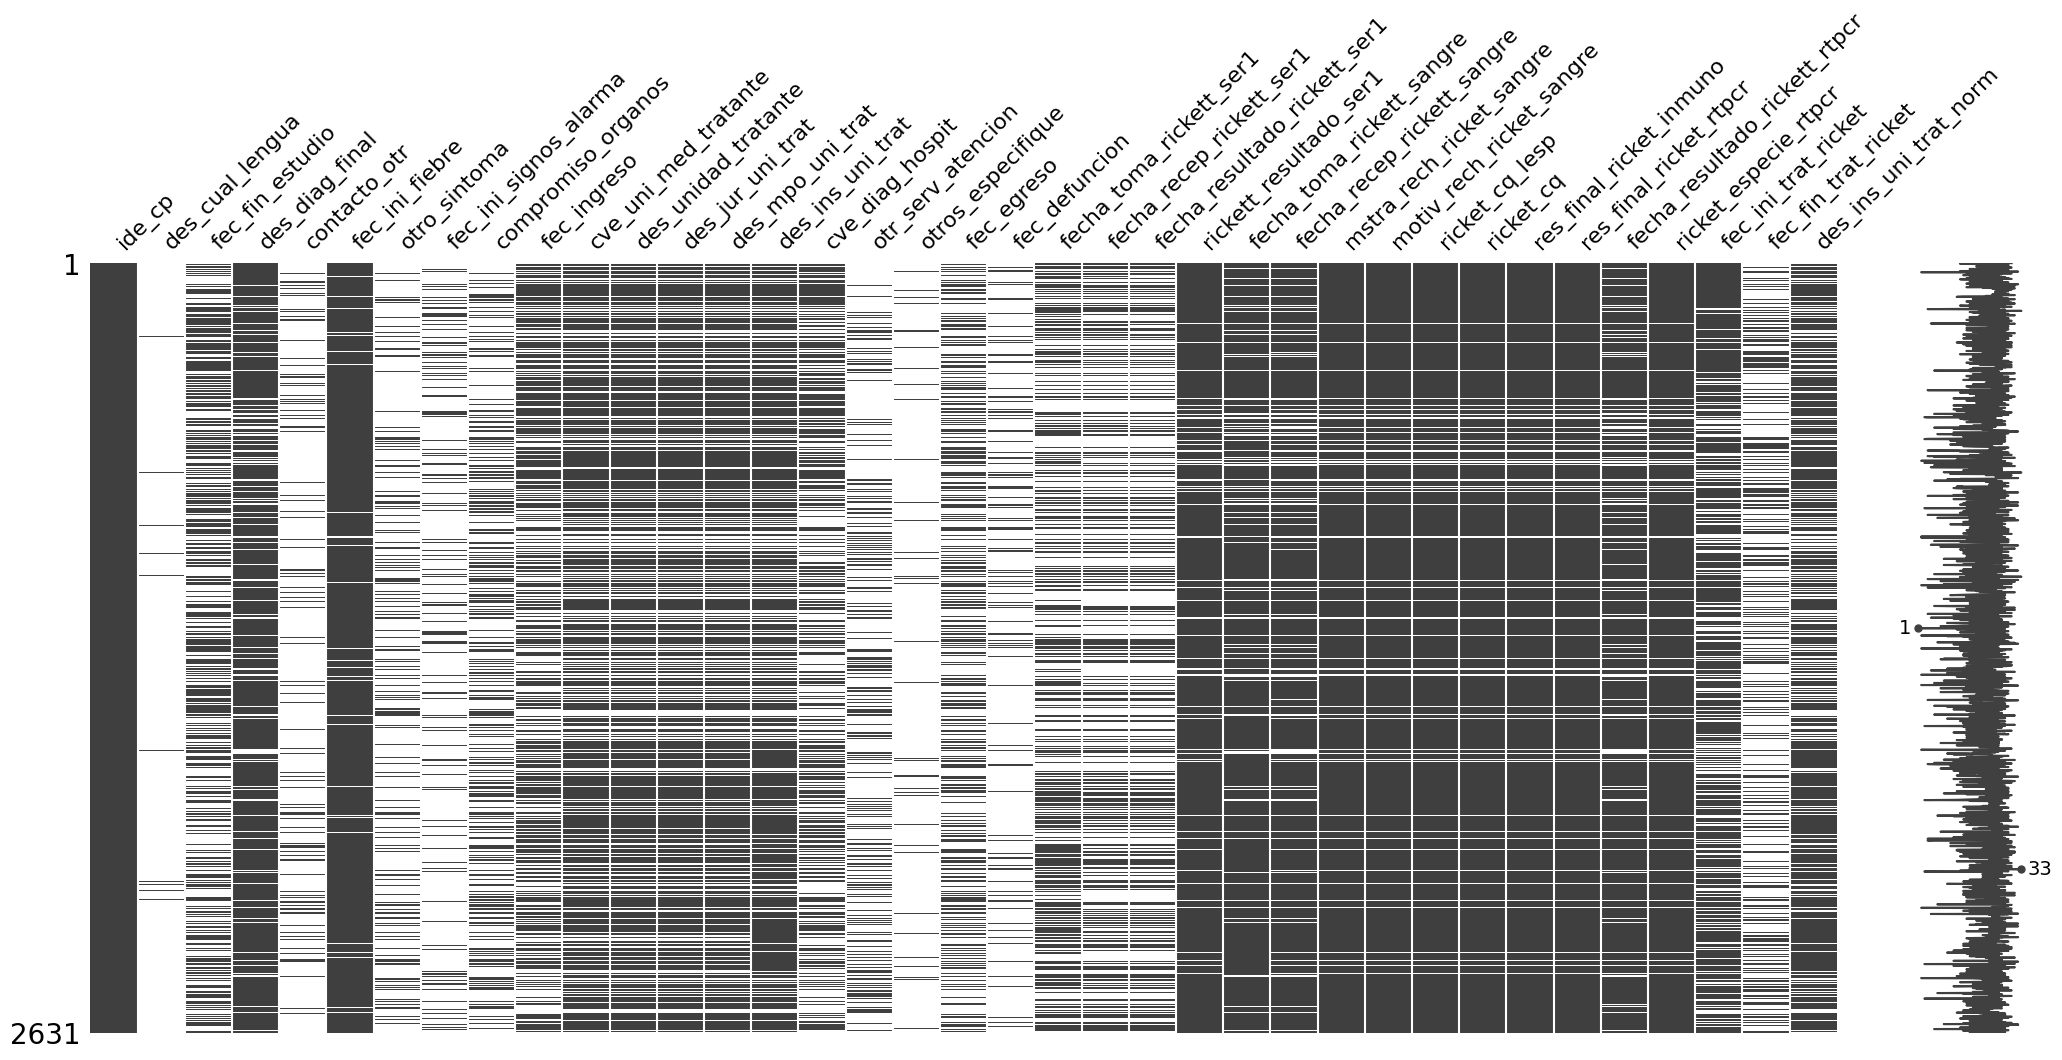

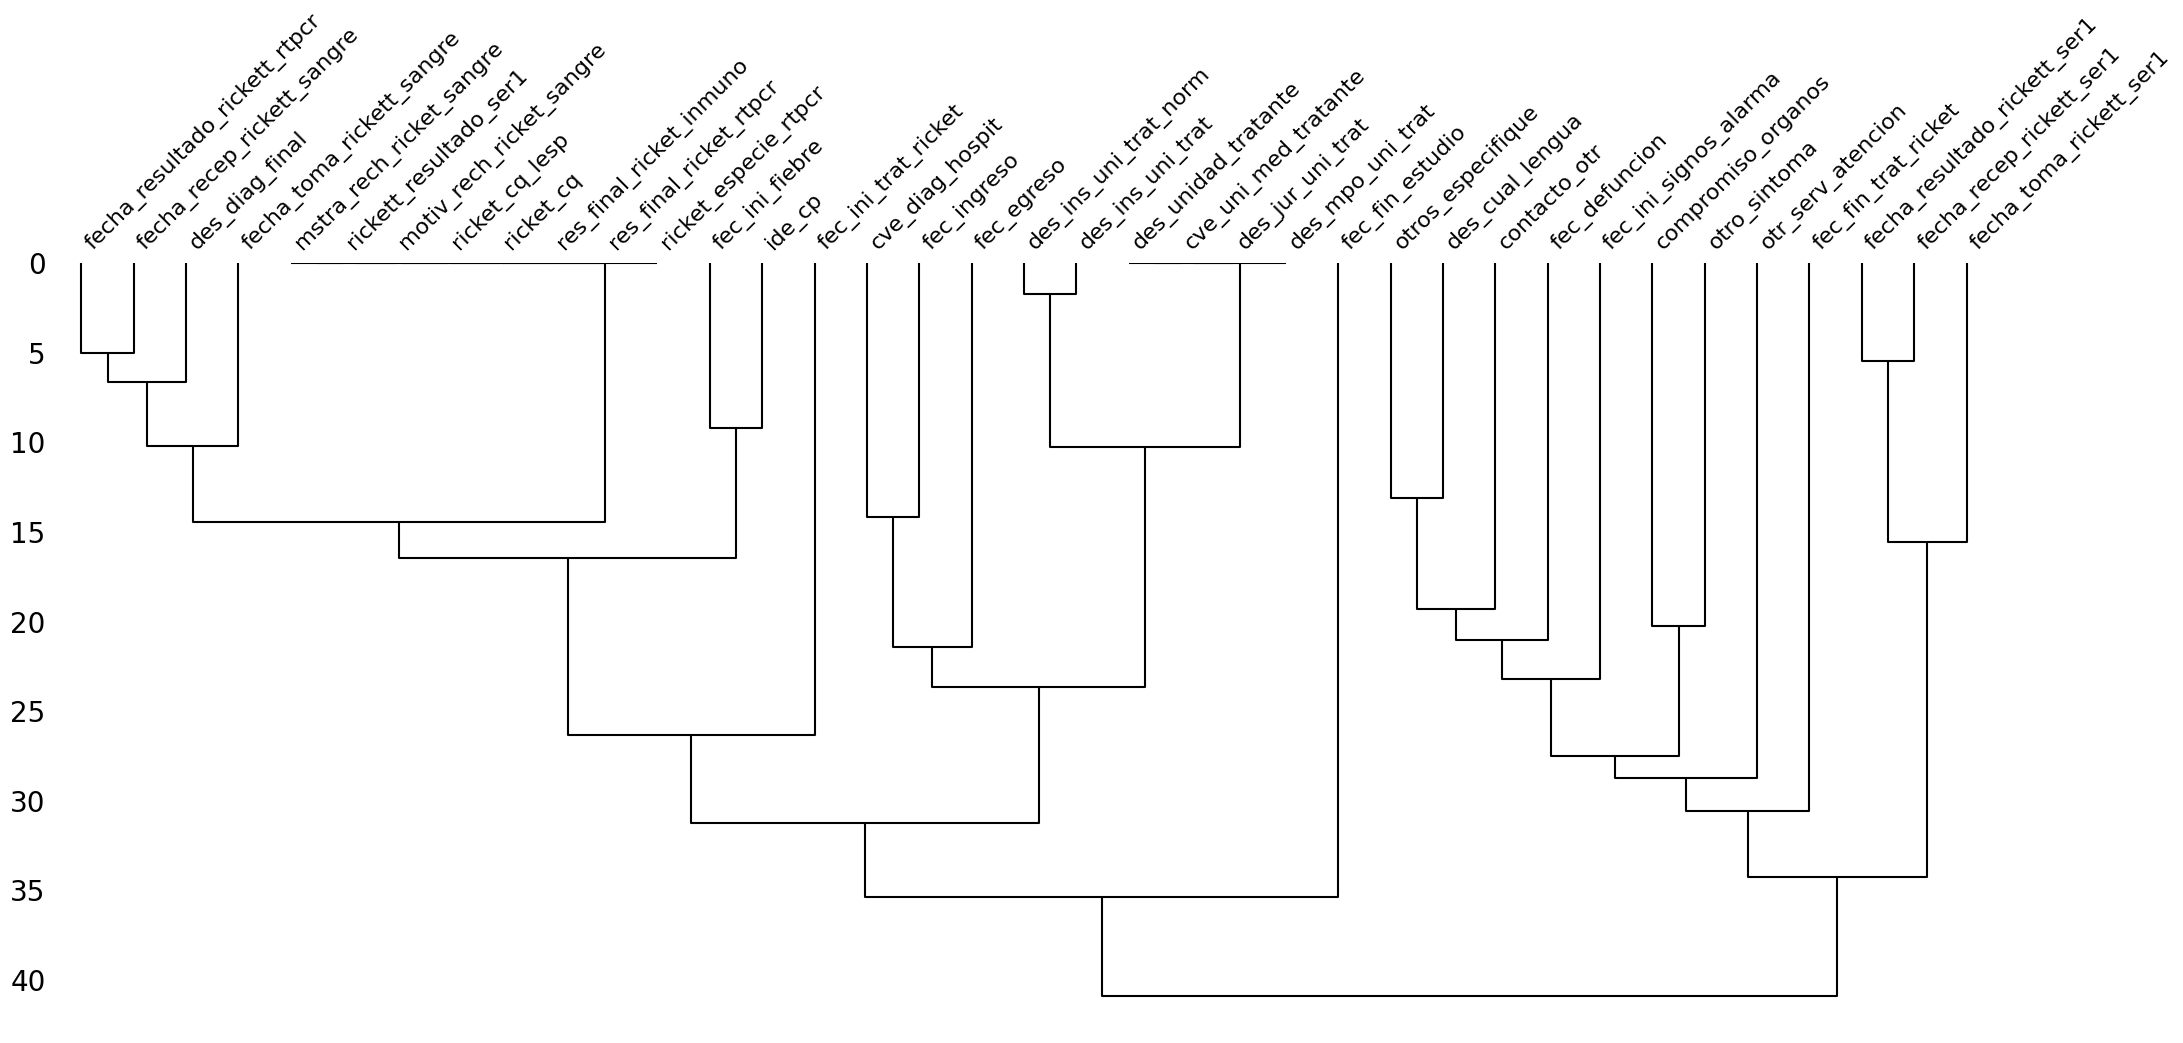

In [34]:
# Identificar columnas que tienen al menos un valor nulo
null_cols = rick.columns[rick.isna().any()].tolist()


# Matriz de completitud
msno.matrix(rick[null_cols])

# Dendrograma: muestra qué variables suelen faltar juntas
msno.dendrogram(rick[null_cols])

<Axes: >

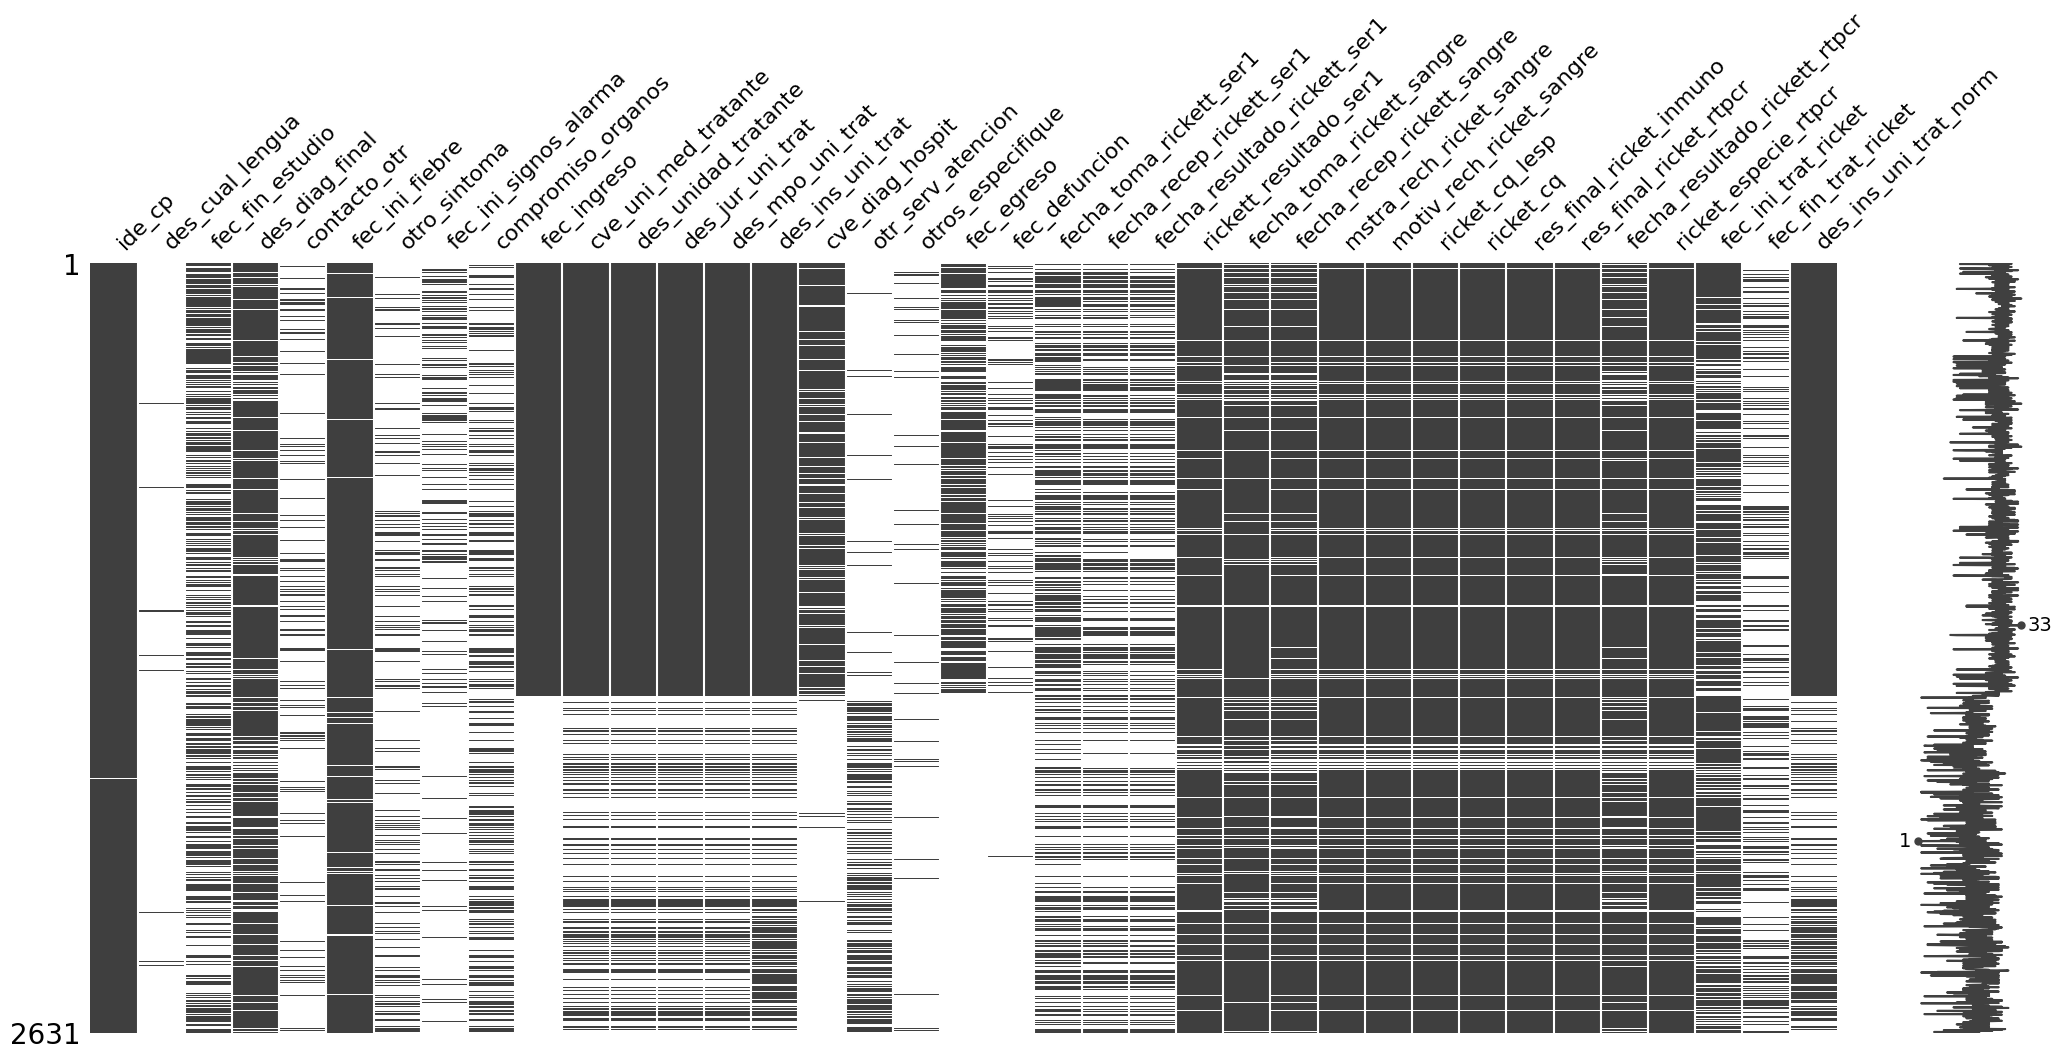

In [11]:
sorted = rick.sort_values('fec_ingreso')
msno.matrix(sorted[null_cols])

## 4. Selección de features

In [35]:
# Eliminar columnas que solo tienen 1 valor único
for col in rick.columns:
    if rick[col].nunique() <= 1:
        print(f"Eliminando columna constante: {col}")
        rick = rick.drop(col, axis=1)

Eliminando columna constante: des_diag_probable


### 4.1 Definir tipo de features

In [36]:
# Columnas datetime

#Extracción de fecha unicamente (sin hora)

# Identificar las columnas que empiezan con 'fec_'
cols_fecha = [col for col in rick.columns if col.startswith(('fec_', 'fecha'))]


for col in cols_fecha:    
    rick[col] = pd.to_datetime(rick[col], errors='coerce')

print(f"Se convirtieron {len(cols_fecha)} columnas.")
print(rick[cols_fecha].dtypes.head(20))

print("Ejemplo de conversión de fecha:")
rick[cols_fecha].head()

Se convirtieron 17 columnas.
fec_sol_aten                     datetime64[us]
fec_ini_estudio                  datetime64[us]
fec_fin_estudio                  datetime64[us]
fec_ini_signos_sint              datetime64[us]
fec_ini_fiebre                   datetime64[us]
fec_ini_signos_alarma            datetime64[us]
fec_ingreso                      datetime64[us]
fec_egreso                       datetime64[us]
fec_defuncion                    datetime64[us]
fecha_toma_rickett_ser1          datetime64[us]
fecha_recep_rickett_ser1         datetime64[us]
fecha_resultado_rickett_ser1     datetime64[us]
fecha_toma_rickett_sangre        datetime64[us]
fecha_recep_rickett_sangre       datetime64[us]
fecha_resultado_rickett_rtpcr    datetime64[us]
fec_ini_trat_ricket              datetime64[us]
fec_fin_trat_ricket              datetime64[us]
dtype: object
Ejemplo de conversión de fecha:


,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_ingreso,fec_egreso,fec_defuncion,fecha_toma_rickett_ser1,fecha_recep_rickett_ser1,fecha_resultado_rickett_ser1,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre,fecha_resultado_rickett_rtpcr,fec_ini_trat_ricket,fec_fin_trat_ricket
0,2022-01-02,2022-01-02,2022-01-09,2021-12-31,2021-12-31,2022-01-01,2022-01-01,2022-02-14,NaT,2022-01-01,2022-01-02,2022-01-09,2022-01-01,2022-01-02,2022-01-05,2022-01-01,2022-01-04
1,2022-01-05,2022-01-05,NaT,2022-01-04,2022-01-04,NaT,NaT,NaT,NaT,2022-01-05,2022-01-12,2022-01-17,2022-01-05,2022-01-12,2022-01-13,2022-01-05,NaT
2,2022-01-05,2022-01-06,2022-01-06,2022-01-02,2022-01-02,NaT,2022-01-05,2022-01-07,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2022-01-06,NaT
3,2022-01-10,2022-01-10,NaT,2022-01-07,2022-01-08,NaT,NaT,NaT,NaT,2022-01-10,2022-01-12,2022-01-17,2022-01-10,2022-01-12,2022-01-13,2022-01-10,NaT
4,2022-01-13,2022-01-14,2022-02-07,2022-01-05,2022-01-05,NaT,2022-01-13,2022-02-01,NaT,2022-01-14,2022-01-17,2022-01-19,NaT,NaT,NaT,2022-01-14,NaT


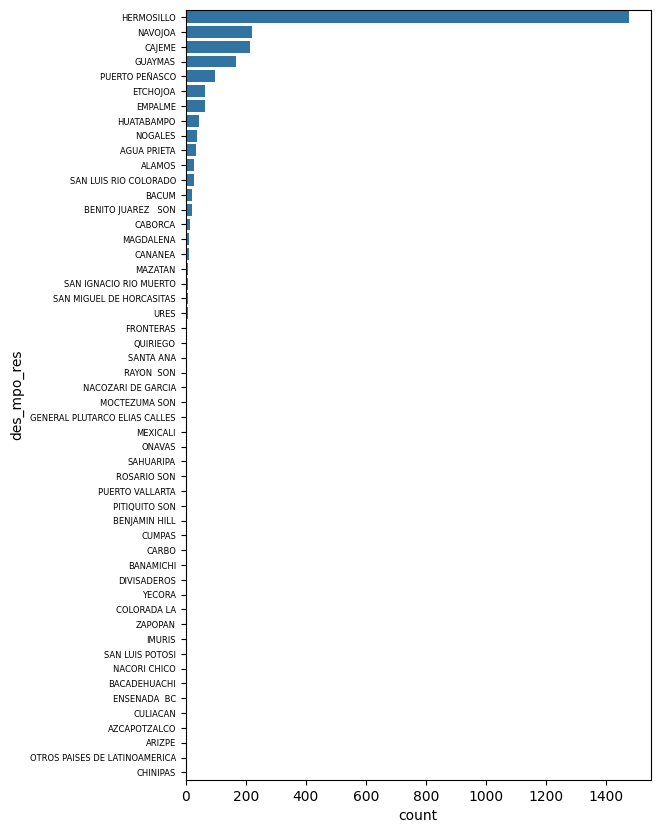

In [11]:
plt.figure(figsize=(6, 10))
sns.countplot(rick['des_mpo_res'], order=rick['des_mpo_res'].value_counts().index)
plt.yticks(size = 6)
plt.show()